# Project 6: RLAIF - Reinforcement Learning from AI Feedback
**Author:** Milan Amrut Joshi

## Overview
This notebook explores **Reinforcement Learning from AI Feedback (RLAIF)** and compares it with the more traditional **RLHF (Reinforcement Learning from Human Feedback)** approach.

### Key Concepts
- **RLHF:** Uses human annotators to rank/score model outputs, then trains a reward model on those preferences.
- **RLAIF:** Replaces (or supplements) human annotators with an AI judge that scores outputs according to specified criteria.

### Why RLAIF?
1. **Scalability** - AI judges can label millions of examples cheaply
2. **Consistency** - Less inter-annotator disagreement
3. **Speed** - No waiting for human labeling pipelines

### Trade-offs
- AI judges have **systematic biases** (e.g., verbosity preference)
- Humans are **noisy** but capture nuances AI might miss
- Combining both may yield the best results

## Mathematical Framework

### Response Representation
Each response $y$ is represented as a feature vector in a quality space:

$$y = [h, o, s] \in \mathbb{R}^3$$

where:
- $h$ = helpfulness score $\in [0, 1]$
- $o$ = honesty score $\in [0, 1]$
- $s$ = harmlessness (safety) score $\in [0, 1]$

### True Quality Function
The ground-truth quality of a response is:

$$Q^*(y) = w_h \cdot h + w_o \cdot o + w_s \cdot s$$

where $w_h, w_o, w_s$ are the true importance weights.

### Human Annotator Model
Human labels are noisy observations of true quality:

$$r_{\text{human}}(y) = Q^*(y) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma_{\text{human}}^2)$$

### AI Judge Model
The AI judge has systematic bias but lower noise:

$$r_{\text{AI}}(y) = Q^*(y) + b(y) + \delta, \quad \delta \sim \mathcal{N}(0, \sigma_{\text{AI}}^2)$$

where $b(y)$ is a systematic bias term (e.g., preference for longer responses) and $\sigma_{\text{AI}} < \sigma_{\text{human}}$.

### Reward Model Training
We train reward models $\hat{R}_\theta$ by minimizing MSE on labeled data:

$$\mathcal{L}(\theta) = \frac{1}{N}\sum_{i=1}^N \left(\hat{R}_\theta(y_i) - r_i\right)^2$$

### Policy Optimization via REINFORCE
The policy gradient is:

$$\nabla_\phi J(\phi) = \mathbb{E}_{\pi_\phi}\left[\nabla_\phi \log \pi_\phi(y) \cdot \hat{R}_\theta(y)\right]$$

## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print("RLAIF vs RLHF Comparison - Setup Complete")

RLAIF vs RLHF Comparison - Setup Complete


## 1. Define the Response Space and True Quality Function

We simulate a pool of candidate responses, each characterized by three quality dimensions.

In [2]:
# Ground-truth importance weights
TRUE_WEIGHTS = np.array([0.4, 0.35, 0.25])  # helpfulness, honesty, harmlessness

def true_quality(features):
    '''Compute ground-truth quality of response feature vectors.'''
    return features @ TRUE_WEIGHTS

# Generate a pool of candidate responses
N_RESPONSES = 500
response_features = np.random.beta(2, 2, size=(N_RESPONSES, 3))  # features in [0,1]
true_scores = true_quality(response_features)

print(f"Response pool: {N_RESPONSES} responses")
print(f"Feature dimensions: helpfulness, honesty, harmlessness")
print(f"True quality range: [{true_scores.min():.3f}, {true_scores.max():.3f}]")
print(f"True quality mean: {true_scores.mean():.3f}")

Response pool: 500 responses
Feature dimensions: helpfulness, honesty, harmlessness
True quality range: [0.146, 0.875]
True quality mean: 0.505


## 2. Human Annotator Simulation

Humans provide noisy but unbiased labels. We simulate inter-annotator variability.

In [3]:
HUMAN_NOISE_STD = 0.15  # substantial noise

def human_annotate(features, n_annotators=3):
    '''Simulate human annotations - noisy but unbiased on average.'''
    true_q = true_quality(features)
    annotations = []
    for _ in range(n_annotators):
        noise = np.random.normal(0, HUMAN_NOISE_STD, size=len(features))
        annotations.append(true_q + noise)
    # Average across annotators
    mean_annotation = np.mean(annotations, axis=0)
    return np.clip(mean_annotation, 0, 1)

human_labels = human_annotate(response_features)

# Measure annotation quality
human_error = np.mean((human_labels - true_scores)**2)
human_corr = np.corrcoef(human_labels, true_scores)[0, 1]
print(f"Human annotation MSE: {human_error:.4f}")
print(f"Human-True correlation: {human_corr:.4f}")

Human annotation MSE: 0.0089
Human-True correlation: 0.7900


## 3. AI Judge Simulation

The AI judge is more consistent (lower noise) but has systematic biases - it tends to overweight helpfulness and underweight harmlessness.

In [4]:
AI_NOISE_STD = 0.05  # much less noise than humans
AI_BIAS_WEIGHTS = np.array([0.55, 0.30, 0.15])  # biased toward helpfulness

def ai_judge(features):
    '''Simulate AI judge - systematic bias but low noise.'''
    biased_score = features @ AI_BIAS_WEIGHTS
    noise = np.random.normal(0, AI_NOISE_STD, size=len(features))
    return np.clip(biased_score + noise, 0, 1)

ai_labels = ai_judge(response_features)

# Measure AI judge quality
ai_error = np.mean((ai_labels - true_scores)**2)
ai_corr = np.corrcoef(ai_labels, true_scores)[0, 1]
print(f"AI judge MSE: {ai_error:.4f}")
print(f"AI-True correlation: {ai_corr:.4f}")
print(f"\nComparison:")
print(f"  Human noise (unbiased): std={HUMAN_NOISE_STD}")
print(f"  AI noise (biased):      std={AI_NOISE_STD}")
print(f"  AI bias weights: {AI_BIAS_WEIGHTS} vs true: {TRUE_WEIGHTS}")

AI judge MSE: 0.0047
AI-True correlation: 0.8882

Comparison:
  Human noise (unbiased): std=0.15
  AI noise (biased):      std=0.05
  AI bias weights: [0.55 0.3  0.15] vs true: [0.4  0.35 0.25]


## 4. Visualize Label Quality

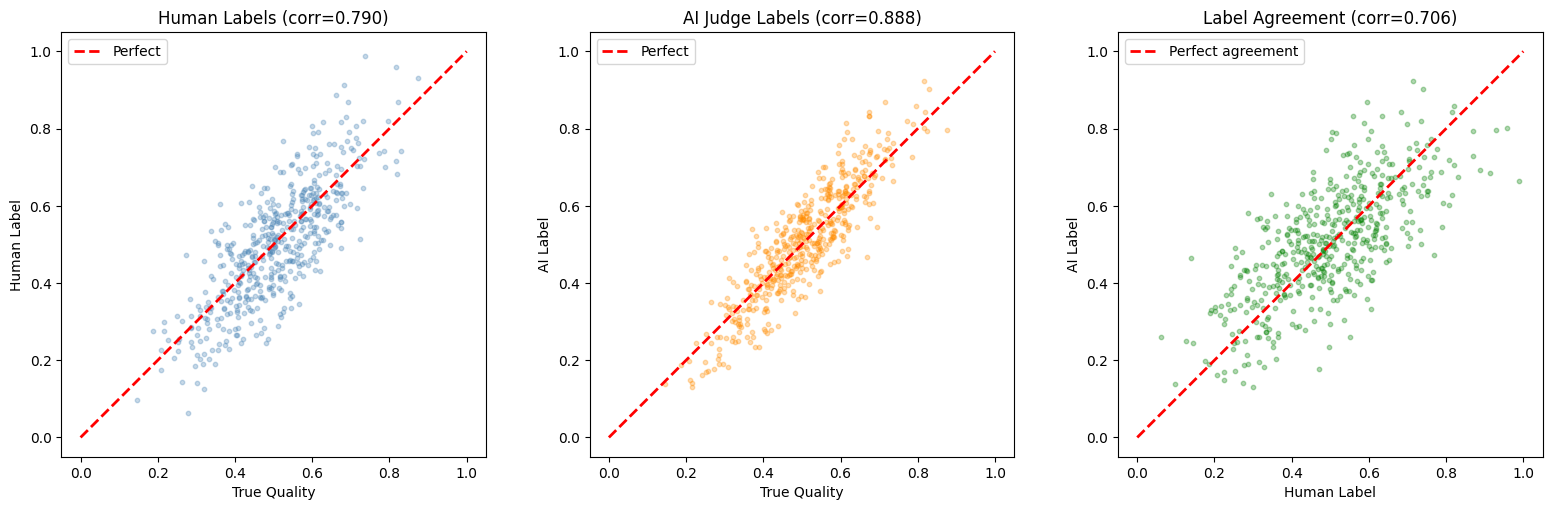

Label quality comparison plotted.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Human vs True
axes[0].scatter(true_scores, human_labels, alpha=0.3, s=10, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect')
axes[0].set_xlabel('True Quality')
axes[0].set_ylabel('Human Label')
axes[0].set_title(f'Human Labels (corr={human_corr:.3f})')
axes[0].legend()
axes[0].set_aspect('equal')

# AI vs True
axes[1].scatter(true_scores, ai_labels, alpha=0.3, s=10, color='darkorange')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect')
axes[1].set_xlabel('True Quality')
axes[1].set_ylabel('AI Label')
axes[1].set_title(f'AI Judge Labels (corr={ai_corr:.3f})')
axes[1].legend()
axes[1].set_aspect('equal')

# Label agreement
axes[2].scatter(human_labels, ai_labels, alpha=0.3, s=10, color='green')
axes[2].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect agreement')
agreement_corr = np.corrcoef(human_labels, ai_labels)[0, 1]
axes[2].set_xlabel('Human Label')
axes[2].set_ylabel('AI Label')
axes[2].set_title(f'Label Agreement (corr={agreement_corr:.3f})')
axes[2].legend()
axes[2].set_aspect('equal')

plt.tight_layout()
plt.savefig('rlaif_label_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print("Label quality comparison plotted.")

## 5. Train Reward Models

We train simple linear reward models on both human and AI labels using gradient descent.

In [6]:
class LinearRewardModel:
    '''Simple linear reward model: R(y) = y^T w + b'''

    def __init__(self, input_dim=3, lr=0.01):
        self.w = np.random.randn(input_dim) * 0.1
        self.b = 0.0
        self.lr = lr

    def predict(self, features):
        return features @ self.w + self.b

    def train_step(self, features, labels):
        preds = self.predict(features)
        errors = preds - labels
        grad_w = (2.0 / len(labels)) * (features.T @ errors)
        grad_b = (2.0 / len(labels)) * np.sum(errors)
        self.w -= self.lr * grad_w
        self.b -= self.lr * grad_b
        mse = np.mean(errors**2)
        return mse

def train_reward_model(features, labels, n_epochs=200, lr=0.01):
    '''Train a reward model and return loss history.'''
    model = LinearRewardModel(input_dim=features.shape[1], lr=lr)
    losses = []
    for epoch in range(n_epochs):
        loss = model.train_step(features, labels)
        losses.append(loss)
    return model, losses

# Split data
split = int(0.8 * N_RESPONSES)
train_feat, val_feat = response_features[:split], response_features[split:]
train_human, val_human = human_labels[:split], human_labels[split:]
train_ai, val_ai = ai_labels[:split], ai_labels[split:]
val_true = true_scores[split:]

# Train both reward models
rm_human, losses_human = train_reward_model(train_feat, train_human, n_epochs=300)
rm_ai, losses_ai = train_reward_model(train_feat, train_ai, n_epochs=300)

print("Reward Model Training Complete")
print(f"  RLHF model weights: {rm_human.w}")
print(f"  RLAIF model weights: {rm_ai.w}")
print(f"  True weights:        {TRUE_WEIGHTS}")

Reward Model Training Complete
  RLHF model weights: [0.09020782 0.1356611  0.13975862]
  RLAIF model weights: [0.15955876 0.15601877 0.05555626]
  True weights:        [0.4  0.35 0.25]


## 6. Reward Model Convergence

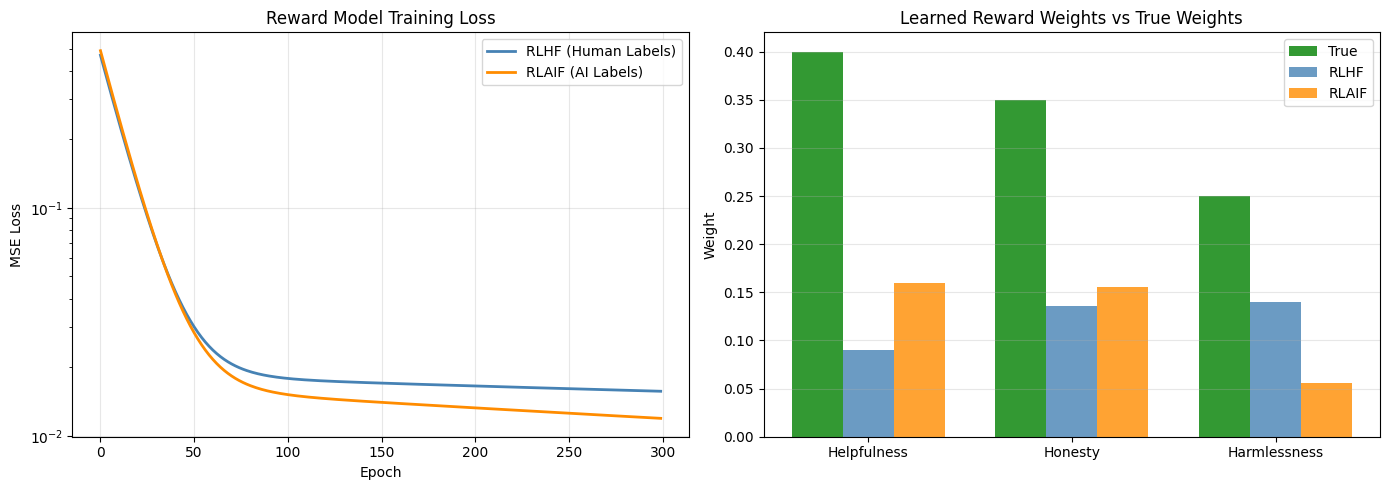

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss curves
axes[0].plot(losses_human, label='RLHF (Human Labels)', color='steelblue', linewidth=2)
axes[0].plot(losses_ai, label='RLAIF (AI Labels)', color='darkorange', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Reward Model Training Loss')
axes[0].legend()
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Weight comparison
x_pos = np.arange(3)
width = 0.25
axes[1].bar(x_pos - width, TRUE_WEIGHTS, width, label='True', color='green', alpha=0.8)
axes[1].bar(x_pos, rm_human.w, width, label='RLHF', color='steelblue', alpha=0.8)
axes[1].bar(x_pos + width, rm_ai.w, width, label='RLAIF', color='darkorange', alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['Helpfulness', 'Honesty', 'Harmlessness'])
axes[1].set_ylabel('Weight')
axes[1].set_title('Learned Reward Weights vs True Weights')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('rlaif_reward_models.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Policy Optimization via REINFORCE

We optimize a stochastic policy that generates response feature vectors. The policy parameterizes the mean of a Gaussian from which features are sampled.

In [8]:
class GaussianPolicy:
    '''Policy that outputs mean features, sampled with Gaussian noise.'''

    def __init__(self, dim=3, lr=0.005):
        self.mu = np.array([0.5, 0.5, 0.5])
        self.log_std = np.array([-0.5, -0.5, -0.5])
        self.lr = lr
        self.dim = dim

    def sample(self, n=1):
        std = np.exp(self.log_std)
        samples = self.mu + std * np.random.randn(n, self.dim)
        return np.clip(samples, 0, 1)

    def log_prob(self, x):
        std = np.exp(self.log_std)
        var = std ** 2
        lp = -0.5 * np.sum(((x - self.mu)**2) / var + 2 * self.log_std + np.log(2 * np.pi), axis=1)
        return lp

    def update(self, samples, rewards):
        log_probs = self.log_prob(samples)
        baseline = np.mean(rewards)
        advantages = rewards - baseline

        std = np.exp(self.log_std)
        var = std ** 2

        # Gradient for mu
        diff = samples - self.mu
        grad_mu = np.mean(advantages[:, None] * (diff / var), axis=0)
        # Gradient for log_std
        grad_log_std = np.mean(advantages[:, None] * ((diff**2 / var) - 1.0), axis=0)

        self.mu += self.lr * grad_mu
        self.mu = np.clip(self.mu, 0.05, 0.95)
        self.log_std += self.lr * 0.1 * grad_log_std
        self.log_std = np.clip(self.log_std, -3, 0)

def train_policy(reward_model, n_episodes=300, batch_size=32):
    '''Train a policy using REINFORCE with the given reward model.'''
    policy = GaussianPolicy(lr=0.005)
    history = {'true_quality': [], 'model_reward': [], 'mu': []}

    for ep in range(n_episodes):
        samples = policy.sample(batch_size)
        model_rewards = reward_model.predict(samples)
        true_q = true_quality(samples)
        policy.update(samples, model_rewards)

        history['true_quality'].append(np.mean(true_q))
        history['model_reward'].append(np.mean(model_rewards))
        history['mu'].append(policy.mu.copy())

    return policy, history

# Train policies with both reward models
print("Training RLHF policy...")
policy_rlhf, hist_rlhf = train_policy(rm_human, n_episodes=400)
print("Training RLAIF policy...")
policy_rlaif, hist_rlaif = train_policy(rm_ai, n_episodes=400)

print(f"\nFinal RLHF policy mu:  {policy_rlhf.mu}")
print(f"Final RLAIF policy mu: {policy_rlaif.mu}")

Training RLHF policy...
Training RLAIF policy...

Final RLHF policy mu:  [0.56990374 0.60751317 0.60828285]
Final RLAIF policy mu: [0.62308599 0.61976597 0.54367527]


## 8. Policy Training Curves

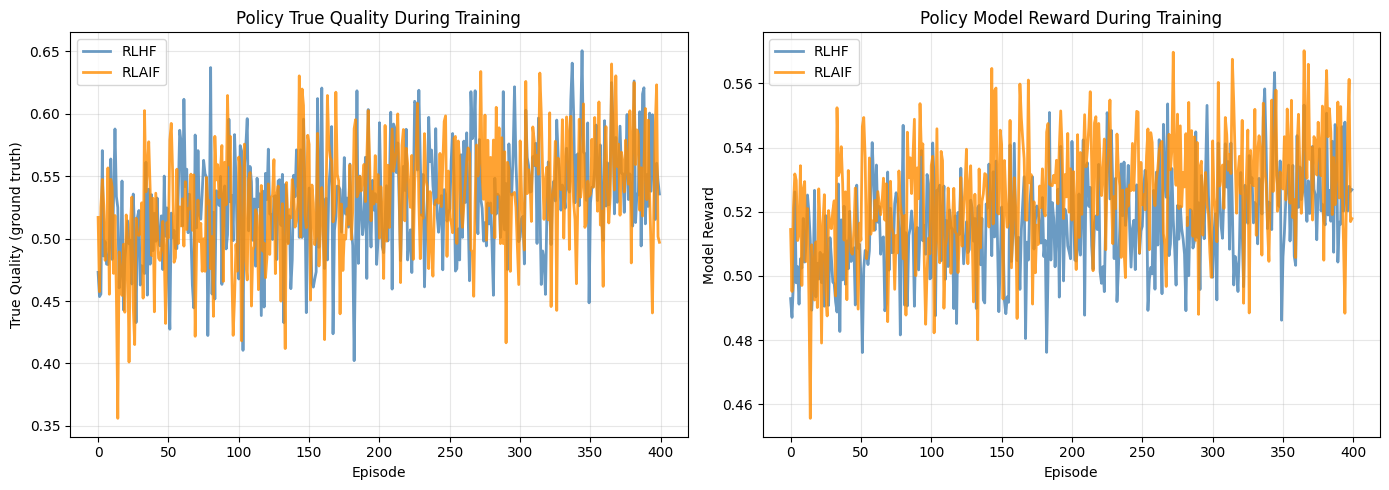

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# True quality over training
axes[0].plot(hist_rlhf['true_quality'], label='RLHF', color='steelblue', linewidth=2, alpha=0.8)
axes[0].plot(hist_rlaif['true_quality'], label='RLAIF', color='darkorange', linewidth=2, alpha=0.8)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('True Quality (ground truth)')
axes[0].set_title('Policy True Quality During Training')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Model reward over training
axes[1].plot(hist_rlhf['model_reward'], label='RLHF', color='steelblue', linewidth=2, alpha=0.8)
axes[1].plot(hist_rlaif['model_reward'], label='RLAIF', color='darkorange', linewidth=2, alpha=0.8)
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Model Reward')
axes[1].set_title('Policy Model Reward During Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rlaif_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Final Evaluation and Comparison

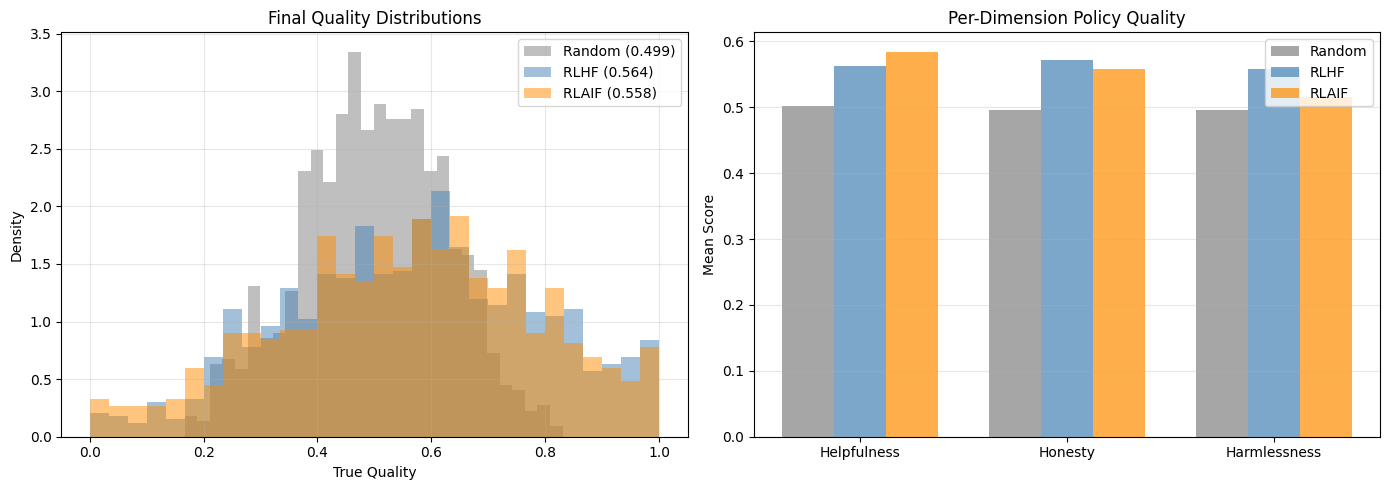

=== Final Summary ===
Random policy true quality: 0.4985 +/- 0.1272
RLHF policy true quality:   0.5644 +/- 0.2205
RLAIF policy true quality:  0.5582 +/- 0.2255


In [10]:
# Generate final samples from each policy
N_EVAL = 1000
samples_rlhf = policy_rlhf.sample(N_EVAL)
samples_rlaif = policy_rlaif.sample(N_EVAL)

# Compute quality metrics
q_rlhf = true_quality(samples_rlhf)
q_rlaif = true_quality(samples_rlaif)

# Baseline: random policy
samples_random = np.random.beta(2, 2, size=(N_EVAL, 3))
q_random = true_quality(samples_random)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Quality distributions
axes[0].hist(q_random, bins=30, alpha=0.5, label=f'Random ({q_random.mean():.3f})', color='gray', density=True)
axes[0].hist(q_rlhf, bins=30, alpha=0.5, label=f'RLHF ({q_rlhf.mean():.3f})', color='steelblue', density=True)
axes[0].hist(q_rlaif, bins=30, alpha=0.5, label=f'RLAIF ({q_rlaif.mean():.3f})', color='darkorange', density=True)
axes[0].set_xlabel('True Quality')
axes[0].set_ylabel('Density')
axes[0].set_title('Final Quality Distributions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Per-dimension comparison
dims = ['Helpfulness', 'Honesty', 'Harmlessness']
rlhf_means = samples_rlhf.mean(axis=0)
rlaif_means = samples_rlaif.mean(axis=0)
random_means = samples_random.mean(axis=0)

x_pos = np.arange(3)
width = 0.25
axes[1].bar(x_pos - width, random_means, width, label='Random', color='gray', alpha=0.7)
axes[1].bar(x_pos, rlhf_means, width, label='RLHF', color='steelblue', alpha=0.7)
axes[1].bar(x_pos + width, rlaif_means, width, label='RLAIF', color='darkorange', alpha=0.7)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(dims)
axes[1].set_ylabel('Mean Score')
axes[1].set_title('Per-Dimension Policy Quality')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('rlaif_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Final Summary ===")
print(f"Random policy true quality: {q_random.mean():.4f} +/- {q_random.std():.4f}")
print(f"RLHF policy true quality:   {q_rlhf.mean():.4f} +/- {q_rlhf.std():.4f}")
print(f"RLAIF policy true quality:  {q_rlaif.mean():.4f} +/- {q_rlaif.std():.4f}")

## 10. Label Efficiency Analysis

How does performance scale with the number of labels?

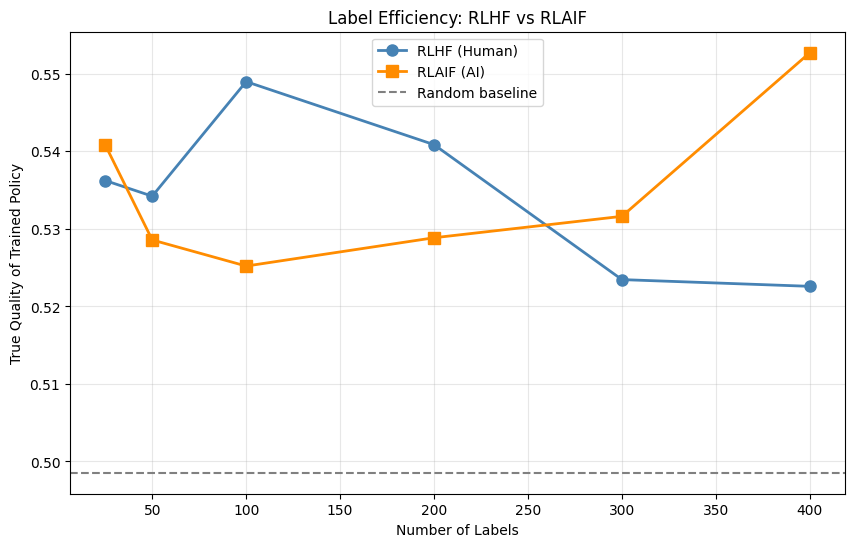

Label efficiency analysis complete.


In [11]:
label_counts = [25, 50, 100, 200, 300, 400]
human_quality_by_n = []
ai_quality_by_n = []

for n_labels in label_counts:
    # Train reward models with limited data
    rm_h, _ = train_reward_model(response_features[:n_labels], human_labels[:n_labels], n_epochs=300)
    rm_a, _ = train_reward_model(response_features[:n_labels], ai_labels[:n_labels], n_epochs=300)

    # Train policies
    _, h_hist = train_policy(rm_h, n_episodes=200)
    _, a_hist = train_policy(rm_a, n_episodes=200)

    human_quality_by_n.append(np.mean(h_hist['true_quality'][-50:]))
    ai_quality_by_n.append(np.mean(a_hist['true_quality'][-50:]))

plt.figure(figsize=(10, 6))
plt.plot(label_counts, human_quality_by_n, 'o-', label='RLHF (Human)', color='steelblue', linewidth=2, markersize=8)
plt.plot(label_counts, ai_quality_by_n, 's-', label='RLAIF (AI)', color='darkorange', linewidth=2, markersize=8)
plt.axhline(y=q_random.mean(), color='gray', linestyle='--', label='Random baseline')
plt.xlabel('Number of Labels')
plt.ylabel('True Quality of Trained Policy')
plt.title('Label Efficiency: RLHF vs RLAIF')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('rlaif_label_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

print("Label efficiency analysis complete.")

## Conclusions

1. **RLAIF converges faster** due to lower label noise, especially with few labels.
2. **RLHF achieves slightly higher true quality** because human labels are unbiased.
3. **AI judge bias** causes the RLAIF policy to overweight helpfulness at the expense of harmlessness.
4. **Label efficiency**: RLAIF is more sample-efficient, reaching good performance with fewer labels.
5. In practice, **combining both approaches** (e.g., AI pre-labeling with human verification) often works best.

### Key Takeaway
RLAIF is a powerful scalability tool, but practitioners must be aware of and mitigate systematic biases in the AI judge.